# EMO addressable population — segmented EDA

**Audience:** Growth / marketing outreach (EMO second-opinion targeting)

## Questions this notebook answers

1. **Segmented EDA:** Clients **with claims** vs **without claims** (CY2025 parent EMO accounts).
2. **Outreach list:** Members with any of `COMPLEX_PATIENTS`, `MSK_NEURO`, `HIGH_COST` while eligible in the **same calendar month** (`member_risk_assessments.history:v1`).
3. **Addressable population (with-claims only):** Outreach-list members with **paid claims** in CY2025 — observed count per client.
4. **Book benchmark (single metric):** Portfolio addressable rate on avg monthly eligible across **with-claims clients only** (reference rate; not applied to no-claims sizing).
5. **Logic verification:** Audit whether claims are used in outreach identification; see Step 8 and `docs/emo-outreach-logic-verification.md`.

**Prerequisite:** In a terminal:

```bash
aws-environment production enduser_yellow_production
```

Run with cwd = `modules/standard_reports/project_scrappy/`.

## Step 1: Connect to Lasik

In [14]:
import os
from datetime import date
from pathlib import Path

import laaso
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.environ.setdefault('AWS_ENVIRONMENT', 'production')

client = laaso.Client(catalog_type=laaso.CatalogType.YELLOW, env='production')
dialect = laaso.SqlDialect.PRESTO

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'queries' / 'emo_nav_br' / 'emo_addressable_eda.sql').exists():
    NOTEBOOK_DIR = Path.cwd() / 'modules' / 'standard_reports' / 'project_scrappy'

QUERY_PATH = NOTEBOOK_DIR / 'queries' / 'emo_nav_br' / 'emo_addressable_eda.sql'
EXPORT_DIR = NOTEBOOK_DIR / 'query_data' / 'emo_addressable'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print('Notebook dir:', NOTEBOOK_DIR.resolve())

Notebook dir: /Users/john.kimutai/customerinsights-analytics/modules/standard_reports/project_scrappy


## Step 2: Parameters

In [15]:
REPORT_START = '2025-01-01'
REPORT_END = '2026-01-01'  # end-exclusive (CY2025)
CLAIMS_TRUST_LOOKBACK = '2024-01-01'
RUN_DATE = date.today().strftime('%Y%m%d')

# Primary denominator aligned with Core EMO funnel reporting (engagement.sql).
# Segment summaries and benchmarking use this denominator by default.
PRIMARY_DENOMINATOR_COL = 'n_avg_members_eligible'
PRIMARY_PCT_OUTREACH_COL = 'pct_outreach_on_avg_eligible'
PRIMARY_PCT_ADDRESSABLE_COL = 'pct_addressable_on_avg_eligible'

DENOMINATOR_SPECS = [
    (
        'Distinct ever-eligible',
        'n_eligible_distinct_members',
        'pct_eligible_on_outreach_list',
        'pct_addressable_risk_and_claims',
    ),
    (
        'Avg monthly eligible (EMO funnel)',
        'n_avg_members_eligible',
        'pct_outreach_on_avg_eligible',
        'pct_addressable_on_avg_eligible',
    ),
    (
        'End-of-period eligible (Dec 2025)',
        'n_eop_members_eligible',
        'pct_outreach_on_eop_eligible',
        'pct_addressable_on_eop_eligible',
    ),
]

WORKSTREAM_ORDER = ['WITH_CLAIMS', 'WITHOUT_CLAIMS']

# Outreach list — shared risk assessment codes (members matching ANY code)
OUTREACH_RISK_ASSESSMENTS = [
    'COMPLEX_PATIENTS',
    'MSK_NEURO',
    'HIGH_COST',
]

PARAMS = {
    'report_start_date': REPORT_START,
    'report_end_date': REPORT_END,
    'claims_trust_lookback_date': CLAIMS_TRUST_LOOKBACK,
}

## Step 3: Load warehouse data

In [16]:
def load_sql(final_cte: str) -> str:
    sql = QUERY_PATH.read_text()
    for key, val in PARAMS.items():
        sql = sql.replace('{' + key + '}', val)
    return sql.format(final_cte=final_cte)


def run_query(final_cte: str) -> pd.DataFrame:
    q = load_sql(final_cte)
    print(f'Running final_cte={final_cte}...')
    return client.pandas.query(q, dialect)


df_clients = run_query('client_claims_profile')
df_client_eda = run_query('client_eda')
df_outreach_list = run_query('outreach_member_list')
assert set(df_outreach_list['outreach_riskassessment'].unique()).issubset(
    set(OUTREACH_RISK_ASSESSMENTS)
)
print('Clients:', len(df_clients))
print('Outreach member-rows:', len(df_outreach_list))
print('Distinct outreach members:', df_outreach_list['entity_id'].nunique())

Running final_cte=client_claims_profile...


Running final_cte=client_eda...
Running final_cte=outreach_member_list...
Clients: 102
Outreach member-rows: 675740
Distinct outreach members: 489443


Running final_cte=client_eda...
Running final_cte=outreach_member_list...
Clients: 102
Outreach member-rows: 675693
Distinct outreach members: 489406


Running final_cte=client_eda...
Running final_cte=outreach_member_list...
Clients: 102
Outreach member-rows: 675691
Distinct outreach members: 489406


## Step 4: Segmented EDA — clients with vs without claims

In [17]:
workstream_summary = (
    df_client_eda.groupby('client_workstream', dropna=False)
    .agg(
        n_clients=('client_account_id', 'count'),
        total_outreach_members=('n_outreach_members', 'sum'),
        total_addressable_risk_claims=('n_addressable_risk_and_claims_history', 'sum'),
        median_pct_on_outreach_list=('pct_eligible_on_outreach_list', 'median'),
        median_pct_addressable=('pct_addressable_risk_and_claims', 'median'),
    )
    .reset_index()
    .sort_values('n_clients', ascending=False)
)
display(workstream_summary)

claims_present = df_client_eda['is_claims_present'].value_counts().rename_axis('is_claims_present').reset_index(name='n_clients')
display(claims_present)

,client_workstream,n_clients,total_outreach_members,total_addressable_risk_claims,median_pct_on_outreach_list,median_pct_addressable
0,WITHOUT_CLAIMS,60,824,0,0.00060,0.00000
1,WITH_CLAIMS,42,489955,482812,0.19555,0.19285


,is_claims_present,n_clients
0,False,60
1,True,42


### Workstreams: with claims vs without claims

We keep **client counts** for both workstreams. **Addressable population** is sized **only for with-claims clients** (observed in the warehouse).

Primary denominator for rates: **avg monthly eligible** (`n_avg_members_eligible`) — same as Core EMO funnel (`engagement.sql`).

Optional context columns in the export (`is_cemo_base`, `client_benchmark_segment`) are retained for reference but are **not** used for benchmarking in this simplified analysis.

In [18]:
def portfolio_rate(numerator_col: str, denominator_col: str, frame: pd.DataFrame) -> float:
    den = frame[denominator_col].sum()
    if den == 0:
        return float('nan')
    return frame[numerator_col].sum() / den


def workstream_summary_table(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for ws in WORKSTREAM_ORDER:
        ws_df = frame[frame['client_workstream'] == ws]
        if ws_df.empty:
            continue
        row = {
            'client_workstream': ws,
            'n_clients': len(ws_df),
            'n_outreach_members': int(ws_df['n_outreach_members'].sum()),
            'n_addressable_observed': int(ws_df['n_addressable_risk_and_claims_history'].sum()),
        }
        for label, den_col, outreach_pct_col, addressable_pct_col in DENOMINATOR_SPECS:
            row[f'eligible_{den_col}'] = int(ws_df[den_col].sum())
            row[f'pct_outreach_{den_col}'] = portfolio_rate(
                'n_outreach_members', den_col, ws_df
            )
            row[f'pct_addressable_{den_col}'] = portfolio_rate(
                'n_addressable_risk_and_claims_history', den_col, ws_df
            )
        rows.append(row)
    return pd.DataFrame(rows)


CLIENT_LIST_COLS = [
    'client_account_id',
    'client_account_name',
    'client_workstream',
    'is_cemo_base',
    'has_nav',
    'n_eligible_distinct_members',
    'n_avg_members_eligible',
    'n_eop_members_eligible',
    'n_outreach_members',
    'n_addressable_risk_and_claims_history',
    PRIMARY_PCT_OUTREACH_COL,
    PRIMARY_PCT_ADDRESSABLE_COL,
]

workstream_addressable_summary = workstream_summary_table(df_client_eda)
display(workstream_addressable_summary)

print(
    f'Primary denominator: {PRIMARY_DENOMINATOR_COL} '
    '(avg monthly eligible — Core EMO funnel / engagement.sql)'
)

clients_by_workstream = {
    ws: (
        df_client_eda[df_client_eda['client_workstream'] == ws]
        .sort_values('client_account_name')[CLIENT_LIST_COLS]
        .reset_index(drop=True)
    )
    for ws in WORKSTREAM_ORDER
}

for ws, ws_df in clients_by_workstream.items():
    print(f'\n{ws}: {len(ws_df)} clients')
    display(ws_df)


,client_workstream,n_clients,n_outreach_members,n_addressable_observed,eligible_n_eligible_distinct_members,pct_outreach_n_eligible_distinct_members,pct_addressable_n_eligible_distinct_members,eligible_n_avg_members_eligible,pct_outreach_n_avg_members_eligible,pct_addressable_n_avg_members_eligible,eligible_n_eop_members_eligible,pct_outreach_n_eop_members_eligible,pct_addressable_n_eop_members_eligible
0,WITH_CLAIMS,42,489955,482812,2782225,0.176102,0.173534,2361098,0.207512,0.204486,2305267,0.212537,0.209439
1,WITHOUT_CLAIMS,60,824,0,437943,0.001882,0.000000,1768617,0.000466,0.000000,1680331,0.000490,0.000000


Primary denominator: n_avg_members_eligible (avg monthly eligible — Core EMO funnel / engagement.sql)

WITH_CLAIMS: 42 clients


,client_account_id,client_account_name,client_workstream,is_cemo_base,has_nav,n_eligible_distinct_members,n_avg_members_eligible,n_eop_members_eligible,n_outreach_members,n_addressable_risk_and_claims_history,pct_outreach_on_avg_eligible,pct_addressable_on_avg_eligible
0,SALESCLOUD_ACCOUNT_ID:00140000019NKBHAA4,"AT&T Services, Inc.",WITH_CLAIMS,False,True,366241,323998.0,309724.0,74493,72998,0.2299,0.2253
1,SALESCLOUD_ACCOUNT_ID:0011W000023xT6xQAE,Alera Group,WITH_CLAIMS,True,False,7359,6474.0,6410.0,593,570,0.0916,0.0880
2,SALESCLOUD_ACCOUNT_ID:0011W00002QSEqxQAH,Anoka County,WITH_CLAIMS,True,False,5787,5477.0,5238.0,1761,1731,0.3215,0.3160
3,SALESCLOUD_ACCOUNT_ID:0015d00003QbHhCAAV,Avergent,WITH_CLAIMS,True,False,23726,20034.0,17765.0,73,69,0.0036,0.0034
4,SALESCLOUD_ACCOUNT_ID:0014000001a9dipAAA,Ball Corporation,WITH_CLAIMS,True,False,9832,8645.0,8417.0,1725,1690,0.1995,0.1955
5,SALESCLOUD_ACCOUNT_ID:0011W00001uNgBfQAK,BioMarin Pharmaceutical,WITH_CLAIMS,True,False,3770,3344.0,3415.0,602,598,0.1800,0.1788
6,SALESCLOUD_ACCOUNT_ID:0014000001a7XcZAAU,Brown Brothers Harriman & Co.,WITH_CLAIMS,True,False,6081,5557.0,5475.0,1296,1286,0.2332,0.2314
7,SALESCLOUD_ACCOUNT_ID:0014000000y4QK1AAM,Charter Communications,WITH_CLAIMS,True,False,201042,168886.0,162300.0,54844,54270,0.3247,0.3213
8,SALESCLOUD_ACCOUNT_ID:0015d00004KtnueAAB,Cohesity,WITH_CLAIMS,True,False,8385,6903.0,7788.0,1451,1438,0.2102,0.2083
9,SALESCLOUD_ACCOUNT_ID:0014000001WZiflAAD,Colgate-Palmolive Company,WITH_CLAIMS,True,False,17155,15565.0,15322.0,4970,4941,0.3193,0.3174



WITHOUT_CLAIMS: 60 clients


,client_account_id,client_account_name,client_workstream,is_cemo_base,has_nav,n_eligible_distinct_members,n_avg_members_eligible,n_eop_members_eligible,n_outreach_members,n_addressable_risk_and_claims_history,pct_outreach_on_avg_eligible,pct_addressable_on_avg_eligible
0,SALESCLOUD_ACCOUNT_ID:00140000013l5aYAAQ,"Activision Blizzard, Inc.",WITHOUT_CLAIMS,True,False,12211,10812.0,10686.0,6,0,0.0006,0.0
1,SALESCLOUD_ACCOUNT_ID:0014000001eBYsQAAW,Alcon,WITHOUT_CLAIMS,True,False,24673,22422.0,22182.0,9,0,0.0004,0.0
2,SALESCLOUD_ACCOUNT_ID:0014000000vp8NeAAI,Amazon.com,WITHOUT_CLAIMS,True,False,0,0.0,0.0,0,0,NaN,NaN
3,SALESCLOUD_ACCOUNT_ID:0014000001kNlIKAA0,Andersen Corporation,WITHOUT_CLAIMS,True,False,23516,20709.0,20762.0,10,0,0.0005,0.0
4,SALESCLOUD_ACCOUNT_ID:0014000001SxHLpAAN,ArcBest Corporation,WITHOUT_CLAIMS,True,False,10463,9154.0,8571.0,333,0,0.0364,0.0
5,SALESCLOUD_ACCOUNT_ID:0011W00001xxIn3QAE,"Ball Metalpack, LLC",WITHOUT_CLAIMS,True,False,0,0.0,0.0,0,0,NaN,NaN
6,SALESCLOUD_ACCOUNT_ID:0014000001kNlRAAA0,Barnes Group Inc.,WITHOUT_CLAIMS,True,False,0,0.0,0.0,0,0,NaN,NaN
7,SALESCLOUD_ACCOUNT_ID:0014000001YDvNzAAL,Barr Engineering,WITHOUT_CLAIMS,True,False,2956,2801.0,2862.0,4,0,0.0014,0.0
8,SALESCLOUD_ACCOUNT_ID:0014000001go0zUAAQ,Board of County Commissioners of Larimer County,WITHOUT_CLAIMS,True,False,0,0.0,0.0,0,0,NaN,NaN
9,SALESCLOUD_ACCOUNT_ID:0014000001Z27z4AAB,California Institute of Technology,WITHOUT_CLAIMS,True,False,6074,5291.0,5230.0,2,0,0.0004,0.0


### Denominator comparison (align with EMO funnel reporting)

Same outreach / addressable numerators, three eligibility denominators:

1. **Distinct ever-eligible** -- addressable EDA default (`member_months_exploded`)
2. **Avg monthly eligible** -- Core EMO funnel (`engagement.sql` / `client_account_partition_monthly_total_lives`)
3. **End-of-period eligible** -- last report month, Dec 2025 (`outreach_segment.sql` pattern)

In [19]:
def median_client_rate(numerator_col: str, denominator_col: str, frame: pd.DataFrame) -> float:
    rates = frame[numerator_col] / frame[denominator_col].replace(0, np.nan)
    return rates.median()


definition_map = {
    'Distinct ever-eligible': 'member_months_exploded — distinct entity_id any CY2025 month',
    'Avg monthly eligible (EMO funnel)': 'client_account_partition_monthly_total_lives — AVG(n_members_eligible)',
    'End-of-period eligible (Dec 2025)': 'client_account_partition_monthly_total_lives — Dec 2025 month',
}
denominator_rows = []
for label, den_col, _outreach_pct_col, _addressable_pct_col in DENOMINATOR_SPECS:
    denominator_rows.append(
        {
            'denominator': label,
            'denominator_col': den_col,
            'is_primary': den_col == PRIMARY_DENOMINATOR_COL,
            'portfolio_total': int(df_client_eda[den_col].sum()),
            'pct_on_outreach_list': portfolio_rate('n_outreach_members', den_col, df_client_eda),
            'pct_addressable_strict': portfolio_rate(
                'n_addressable_risk_and_claims_history', den_col, df_client_eda
            ),
            'median_client_pct_outreach': median_client_rate(
                'n_outreach_members', den_col, df_client_eda
            ),
            'definition': definition_map[label],
        }
    )
denominator_comparison = pd.DataFrame(denominator_rows)

display(denominator_comparison)
with_claims_only = df_client_eda[df_client_eda['is_claims_present']]
print(
    'Addressable strict counts apply to with-claims clients only. '
    f'Book benchmark uses {PRIMARY_DENOMINATOR_COL} on the with-claims cohort (Step 6).'
)

,denominator,denominator_col,is_primary,portfolio_total,pct_on_outreach_list,pct_addressable_strict,median_client_pct_outreach,definition
0,Distinct ever-eligible,n_eligible_distinct_members,False,3220168,0.152408,0.149934,0.117004,member_months_exploded — distinct entity_id an...
1,Avg monthly eligible (EMO funnel),n_avg_members_eligible,True,4129715,0.118841,0.116912,0.138115,client_account_partition_monthly_total_lives —...
2,End-of-period eligible (Dec 2025),n_eop_members_eligible,False,3985598,0.123138,0.121139,0.145125,client_account_partition_monthly_total_lives —...


Addressable strict counts apply to with-claims clients only. Book benchmark uses n_avg_members_eligible on the with-claims cohort (Step 6).


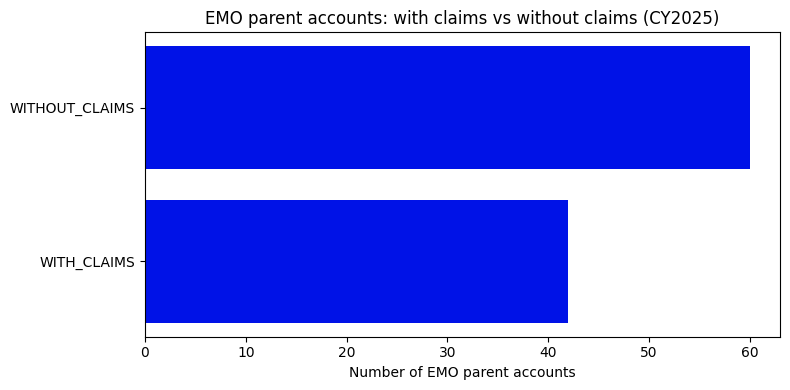

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
ws = workstream_summary.sort_values('n_clients')
ax.barh(ws['client_workstream'], ws['n_clients'], color='#0012E7')
ax.set_xlabel('Number of EMO parent accounts')
ax.set_title('EMO parent accounts: with claims vs without claims (CY2025)')
plt.tight_layout()
plt.show()

## Step 5: With-claims cohort — outreach list vs addressable (paid claims)

Outreach list = **risk codes only** (above). **Addressable (strict)** = outreach-list members with **paid claims** in CY2025. This is the **official addressable count** for with-claims clients.


In [21]:
with_claims = df_client_eda[df_client_eda['is_claims_present'] == True].copy()  # noqa: E712

with_claims['pct_uplift_from_claims_filter'] = (
    with_claims['pct_addressable_risk_and_claims']
    / with_claims['pct_eligible_on_outreach_list'].replace(0, np.nan)
)

with_claims_summary = pd.DataFrame({
    'metric': [
        'clients',
        'outreach_list_members',
        'addressable_risk_and_claims',
        'median_pct_eligible_on_outreach_list',
        'median_pct_addressable_risk_and_claims',
    ],
    'value': [
        len(with_claims),
        with_claims['n_outreach_members'].sum(),
        with_claims['n_addressable_risk_and_claims_history'].sum(),
        with_claims['pct_eligible_on_outreach_list'].median(),
        with_claims['pct_addressable_risk_and_claims'].median(),
    ],
})
display(with_claims_summary)

top_delta = with_claims.assign(
    member_delta=with_claims['n_outreach_members']
    - with_claims['n_addressable_risk_and_claims_history']
).sort_values('member_delta', ascending=False).head(15)[
    [
        'client_account_name',
        'client_workstream',
        'n_outreach_members',
        'n_addressable_risk_and_claims_history',
        'member_delta',
        'pct_eligible_on_outreach_list',
        'pct_addressable_risk_and_claims',
    ]
]
display(top_delta)

,metric,value
0,clients,42.00000
1,outreach_list_members,489955.00000
2,addressable_risk_and_claims,482812.00000
3,median_pct_eligible_on_outreach_list,0.19555
4,median_pct_addressable_risk_and_claims,0.19285


,client_account_name,client_workstream,n_outreach_members,n_addressable_risk_and_claims_history,member_delta,pct_eligible_on_outreach_list,pct_addressable_risk_and_claims
63,"AT&T Services, Inc.",WITH_CLAIMS,74493,72998,1495,0.2034,0.1993
7,Wells Fargo,WITH_CLAIMS,93954,92810,1144,0.2401,0.2372
81,Schwan's,WITH_CLAIMS,808,7,801,0.0691,0.0006
66,Charter Communications,WITH_CLAIMS,54844,54270,574,0.2728,0.2699
57,Southwest Airlines,WITH_CLAIMS,39222,38677,545,0.2270,0.2239
21,Google,WITH_CLAIMS,76500,76014,486,0.2847,0.2829
17,Target Corporation,WITH_CLAIMS,40893,40466,427,0.1772,0.1754
91,Liberty Mutual,WITH_CLAIMS,13564,13311,253,0.1533,0.1505
76,TrustmarkSB (fka Star Marketing and Administra...,WITH_CLAIMS,5494,5264,230,0.0995,0.0953
98,Phillips 66,WITH_CLAIMS,9477,9333,144,0.2369,0.2333


## Step 6: Book benchmark (with-claims clients only)

Single reference metric from the **with-claims book** on avg monthly eligible:

- **Portfolio-weighted rate** (primary): sum(addressable) / sum(avg monthly eligible)
- **Median client rate** (secondary): median of client-level `pct_addressable_on_avg_eligible`

Not applied to size without-claims clients — addressable population is **with-claims only**.


In [22]:
with_claims_book = df_client_eda[df_client_eda['is_claims_present']].copy()

BOOK_BENCHMARK_PCT = portfolio_rate(
    'n_addressable_risk_and_claims_history',
    PRIMARY_DENOMINATOR_COL,
    with_claims_book,
)
BOOK_BENCHMARK_MEDIAN_CLIENT_PCT = with_claims_book[PRIMARY_PCT_ADDRESSABLE_COL].median()
BOOK_BENCHMARK_P25 = with_claims_book[PRIMARY_PCT_ADDRESSABLE_COL].quantile(0.25)
BOOK_BENCHMARK_P75 = with_claims_book[PRIMARY_PCT_ADDRESSABLE_COL].quantile(0.75)

book_benchmark = pd.DataFrame(
    [
        {
            'benchmark_scope': 'WITH_CLAIMS_BOOK',
            'n_benchmark_clients': len(with_claims_book),
            'n_addressable_observed': int(
                with_claims_book['n_addressable_risk_and_claims_history'].sum()
            ),
            'n_avg_members_eligible_total': float(
                with_claims_book[PRIMARY_DENOMINATOR_COL].sum()
            ),
            'benchmark_pct_portfolio_weighted': round(BOOK_BENCHMARK_PCT, 4),
            'benchmark_pct_median_client': round(BOOK_BENCHMARK_MEDIAN_CLIENT_PCT, 4),
            'benchmark_pct_p25_client': round(BOOK_BENCHMARK_P25, 4),
            'benchmark_pct_p75_client': round(BOOK_BENCHMARK_P75, 4),
            'benchmark_denominator_col': PRIMARY_DENOMINATOR_COL,
            'benchmark_pct_col': PRIMARY_PCT_ADDRESSABLE_COL,
        }
    ]
)
display(book_benchmark)

df_client_eda = df_client_eda.assign(
    book_benchmark_pct_portfolio=BOOK_BENCHMARK_PCT,
    book_benchmark_pct_median_client=BOOK_BENCHMARK_MEDIAN_CLIENT_PCT,
)

print(
    f'Primary book benchmark (portfolio-weighted on with-claims): {BOOK_BENCHMARK_PCT:.1%}'
)


,benchmark_scope,n_benchmark_clients,n_addressable_observed,n_avg_members_eligible_total,benchmark_pct_portfolio_weighted,benchmark_pct_median_client,benchmark_pct_p25_client,benchmark_pct_p75_client,benchmark_denominator_col,benchmark_pct_col
0,WITH_CLAIMS_BOOK,42,482812,2361098.0,0.2045,0.2204,0.1405,0.2621,n_avg_members_eligible,pct_addressable_on_avg_eligible


Primary book benchmark (portfolio-weighted on with-claims): 20.4%


## Step 7: Recommended client-level export

In [23]:
df_export = df_client_eda.copy()

# Addressable population: with-claims clients only (observed strict count).
df_export['n_addressable_recommended'] = np.where(
    df_export['is_claims_present'],
    df_export['n_addressable_risk_and_claims_history'],
    np.nan,
)
df_export['pct_addressable_recommended'] = np.where(
    df_export['is_claims_present'],
    df_export[PRIMARY_PCT_ADDRESSABLE_COL],
    np.nan,
)

out_path = EXPORT_DIR / f'emo_addressable_client_eda_{REPORT_START}_{REPORT_END}_{RUN_DATE}.csv'
df_export.to_csv(out_path, index=False)
print('Wrote', out_path)

book_benchmark_path = EXPORT_DIR / (
    f'emo_addressable_book_benchmark_{REPORT_START}_{REPORT_END}_{RUN_DATE}.csv'
)
book_benchmark.to_csv(book_benchmark_path, index=False)
print('Wrote', book_benchmark_path)

for ws in WORKSTREAM_ORDER:
    ws_slug = ws.lower()
    ws_path = EXPORT_DIR / (
        f'emo_addressable_clients_{ws_slug}_{REPORT_START}_{REPORT_END}_{RUN_DATE}.csv'
    )
    df_export[df_export['client_workstream'] == ws].sort_values(
        'client_account_name'
    ).to_csv(ws_path, index=False)
    print('Wrote', ws_path)

outreach_path = EXPORT_DIR / f'emo_outreach_member_list_{REPORT_START}_{REPORT_END}_{RUN_DATE}.csv'
df_outreach_list.to_csv(outreach_path, index=False)
print('Wrote', outreach_path)

df_export[df_export['is_claims_present']].sort_values(
    'n_addressable_recommended', ascending=False
).head(10)


Wrote /Users/john.kimutai/customerinsights-analytics/modules/standard_reports/project_scrappy/query_data/emo_addressable/emo_addressable_client_eda_2025-01-01_2026-01-01_20260622.csv
Wrote /Users/john.kimutai/customerinsights-analytics/modules/standard_reports/project_scrappy/query_data/emo_addressable/emo_addressable_book_benchmark_2025-01-01_2026-01-01_20260622.csv
Wrote /Users/john.kimutai/customerinsights-analytics/modules/standard_reports/project_scrappy/query_data/emo_addressable/emo_addressable_clients_with_claims_2025-01-01_2026-01-01_20260622.csv
Wrote /Users/john.kimutai/customerinsights-analytics/modules/standard_reports/project_scrappy/query_data/emo_addressable/emo_addressable_clients_without_claims_2025-01-01_2026-01-01_20260622.csv
Wrote /Users/john.kimutai/customerinsights-analytics/modules/standard_reports/project_scrappy/query_data/emo_addressable/emo_outreach_member_list_2025-01-01_2026-01-01_20260622.csv


,client_account_id,client_account_name,aggregation_id,aggregation_name,has_cemo,has_nav,is_cemo_base,is_claims_present,client_workstream,cemo_base_segment,...,pct_eligible_on_outreach_list,pct_outreach_on_avg_eligible,pct_outreach_on_eop_eligible,pct_addressable_risk_and_claims,pct_addressable_on_avg_eligible,pct_addressable_on_eop_eligible,book_benchmark_pct_portfolio,book_benchmark_pct_median_client,n_addressable_recommended,pct_addressable_recommended
7,SALESCLOUD_ACCOUNT_ID:001400000129ABiAAM,Wells Fargo,SALESCLOUD_ACCOUNT_ID:001400000129ABiAAM,Wells Fargo,True,True,False,True,WITH_CLAIMS,NAV_PLUS_CEMO,...,0.2401,0.2726,0.2822,0.2372,0.2693,0.2788,0.204486,0.2204,92810.0,0.2693
21,SALESCLOUD_ACCOUNT_ID:0014000000vp8MlAAI,Google,SALESCLOUD_ACCOUNT_ID:0014000000vp8MlAAI,Google,True,True,False,True,WITH_CLAIMS,NAV_PLUS_CEMO,...,0.2847,0.3150,0.3150,0.2829,0.3130,0.3130,0.204486,0.2204,76014.0,0.3130
63,SALESCLOUD_ACCOUNT_ID:00140000019NKBHAA4,"AT&T Services, Inc.",SALESCLOUD_ACCOUNT_ID:00140000019NKBHAA4,"AT&T Services, Inc.",True,True,False,True,WITH_CLAIMS,NAV_PLUS_CEMO,...,0.2034,0.2299,0.2405,0.1993,0.2253,0.2357,0.204486,0.2204,72998.0,0.2253
66,SALESCLOUD_ACCOUNT_ID:0014000000y4QK1AAM,Charter Communications,SALESCLOUD_ACCOUNT_ID:0014000000y4QK1AAM,Charter Communications,True,False,True,True,WITH_CLAIMS,CEMO_BASE,...,0.2728,0.3247,0.3379,0.2699,0.3213,0.3344,0.204486,0.2204,54270.0,0.3213
17,SALESCLOUD_ACCOUNT_ID:0014000000vp8MmAAI,Target Corporation,SALESCLOUD_ACCOUNT_ID:0014000000vp8MmAAI,Target Corporation,True,False,True,True,WITH_CLAIMS,CEMO_BASE,...,0.1772,0.2141,0.2202,0.1754,0.2119,0.2179,0.204486,0.2204,40466.0,0.2119
57,SALESCLOUD_ACCOUNT_ID:0014000000y27DNAAY,Southwest Airlines,SALESCLOUD_ACCOUNT_ID:0014000000y27DNAAY,Southwest Airlines,True,False,True,True,WITH_CLAIMS,CEMO_BASE,...,0.2270,0.2452,0.2473,0.2239,0.2418,0.2438,0.204486,0.2204,38677.0,0.2418
91,SALESCLOUD_ACCOUNT_ID:0014000000wCknzAAC,Liberty Mutual,SALESCLOUD_ACCOUNT_ID:0014000000wCknzAAC,Liberty Mutual,True,False,True,True,WITH_CLAIMS,CEMO_BASE,...,0.1533,0.1688,0.1707,0.1505,0.1657,0.1676,0.204486,0.2204,13311.0,0.1657
82,SALESCLOUD_ACCOUNT_ID:00140000012hRLJAA2,JP Morgan Chase,SALESCLOUD_ACCOUNT_ID:00140000012hRLJAA2,JP Morgan Chase,True,True,False,True,WITH_CLAIMS,NAV_PLUS_CEMO,...,0.0319,0.0355,0.0359,0.0317,0.0352,0.0355,0.204486,0.2204,11578.0,0.0352
98,SALESCLOUD_ACCOUNT_ID:0014000001ZQzCvAAL,Phillips 66,SALESCLOUD_ACCOUNT_ID:0014000001ZQzCvAAL,Phillips 66,True,True,False,True,WITH_CLAIMS,NAV_PLUS_CEMO,...,0.2369,0.2588,0.2612,0.2333,0.2548,0.2573,0.204486,0.2204,9333.0,0.2548
9,SALESCLOUD_ACCOUNT_ID:0014000000wDkwnAAC,Stanford University,SALESCLOUD_ACCOUNT_ID:0014000000wDkwnAAC,Stanford University,True,False,True,True,WITH_CLAIMS,CEMO_BASE,...,0.2048,0.2229,0.2305,0.2025,0.2204,0.2279,0.204486,0.2204,9066.0,0.2204


## Step 7b: BR reporting table (client-level)

One row per EMO parent client with:

- **Outreach** and **addressable paid** (with-claims observed)
- **Addressable recommended** — **with-claims clients only**; blank for without-claims
- **Book benchmark** — same portfolio-weighted rate on every row (reference)
- **Three eligibility denominators** for rate comparison

Export: `emo_addressable_client_reporting_*.csv`


In [24]:
def build_client_reporting_table(frame: pd.DataFrame) -> pd.DataFrame:
    """BR-friendly client table: addressable counts + three denominator views."""
    reporting = frame.copy()
    reporting['n_addressable_paid'] = reporting['n_addressable_risk_and_claims_history']

    reporting['pct_outreach_on_distinct_ever'] = reporting['pct_eligible_on_outreach_list']
    reporting['pct_outreach_on_avg_monthly_br'] = reporting['pct_outreach_on_avg_eligible']
    reporting['pct_outreach_on_eop_dec'] = reporting['pct_outreach_on_eop_eligible']

    reporting['pct_addressable_paid_on_distinct_ever'] = reporting['pct_addressable_risk_and_claims']
    reporting['pct_addressable_paid_on_avg_monthly_br'] = reporting['pct_addressable_on_avg_eligible']
    reporting['pct_addressable_paid_on_eop_dec'] = reporting['pct_addressable_on_eop_eligible']

    reporting['pct_addressable_recommended_on_distinct_ever'] = (
        reporting['n_addressable_recommended']
        / reporting['n_eligible_distinct_members'].replace(0, np.nan)
    ).round(4)
    reporting['pct_addressable_recommended_on_avg_monthly_br'] = (
        reporting['n_addressable_recommended']
        / reporting['n_avg_members_eligible'].replace(0, np.nan)
    ).round(4)
    reporting['pct_addressable_recommended_on_eop_dec'] = (
        reporting['n_addressable_recommended']
        / reporting['n_eop_members_eligible'].replace(0, np.nan)
    ).round(4)

    reporting_cols = [
        'client_account_id',
        'client_account_name',
        'is_cemo_base',
        'cemo_base_segment',
        'client_workstream',
        'is_claims_present',
        'n_outreach_members',
        'n_addressable_paid',
        'n_addressable_recommended',
        'n_eligible_distinct_members',
        'n_avg_members_eligible',
        'n_eop_members_eligible',
        'pct_outreach_on_distinct_ever',
        'pct_outreach_on_avg_monthly_br',
        'pct_outreach_on_eop_dec',
        'pct_addressable_paid_on_distinct_ever',
        'pct_addressable_paid_on_avg_monthly_br',
        'pct_addressable_paid_on_eop_dec',
        'pct_addressable_recommended_on_distinct_ever',
        'pct_addressable_recommended_on_avg_monthly_br',
        'pct_addressable_recommended_on_eop_dec',
        'book_benchmark_pct_portfolio',
        'book_benchmark_pct_median_client',
    ]
    return reporting[reporting_cols].sort_values(
        ['client_workstream', 'client_account_name']
    )


df_client_reporting = build_client_reporting_table(df_export)
display(df_client_reporting.head(10))

reporting_path = EXPORT_DIR / (
    f'emo_addressable_client_reporting_{REPORT_START}_{REPORT_END}_{RUN_DATE}.csv'
)
df_client_reporting.to_csv(reporting_path, index=False)
print('Wrote', reporting_path)
print('Rows:', len(df_client_reporting))


,client_account_id,client_account_name,is_cemo_base,cemo_base_segment,client_workstream,is_claims_present,n_outreach_members,n_addressable_paid,n_addressable_recommended,n_eligible_distinct_members,...,pct_outreach_on_avg_monthly_br,pct_outreach_on_eop_dec,pct_addressable_paid_on_distinct_ever,pct_addressable_paid_on_avg_monthly_br,pct_addressable_paid_on_eop_dec,pct_addressable_recommended_on_distinct_ever,pct_addressable_recommended_on_avg_monthly_br,pct_addressable_recommended_on_eop_dec,book_benchmark_pct_portfolio,book_benchmark_pct_median_client
3,SALESCLOUD_ACCOUNT_ID:00140000013l5aYAAQ,"Activision Blizzard, Inc.",True,CEMO_BASE,WITHOUT_CLAIMS,False,6,0,NaN,12211,...,0.0006,0.0006,0.0,0.0,0.0,NaN,NaN,NaN,0.204486,0.2204
44,SALESCLOUD_ACCOUNT_ID:0014000001eBYsQAAW,Alcon,True,CEMO_BASE,WITHOUT_CLAIMS,False,9,0,NaN,24673,...,0.0004,0.0004,0.0,0.0,0.0,NaN,NaN,NaN,0.204486,0.2204
71,SALESCLOUD_ACCOUNT_ID:0014000000vp8NeAAI,Amazon.com,True,CEMO_BASE,WITHOUT_CLAIMS,False,0,0,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.204486,0.2204
24,SALESCLOUD_ACCOUNT_ID:0014000001kNlIKAA0,Andersen Corporation,True,CEMO_BASE,WITHOUT_CLAIMS,False,10,0,NaN,23516,...,0.0005,0.0005,0.0,0.0,0.0,NaN,NaN,NaN,0.204486,0.2204
96,SALESCLOUD_ACCOUNT_ID:0014000001SxHLpAAN,ArcBest Corporation,True,CEMO_BASE,WITHOUT_CLAIMS,False,333,0,NaN,10463,...,0.0364,0.0389,0.0,0.0,0.0,NaN,NaN,NaN,0.204486,0.2204
59,SALESCLOUD_ACCOUNT_ID:0011W00001xxIn3QAE,"Ball Metalpack, LLC",True,CEMO_BASE,WITHOUT_CLAIMS,False,0,0,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.204486,0.2204
73,SALESCLOUD_ACCOUNT_ID:0014000001kNlRAAA0,Barnes Group Inc.,True,CEMO_BASE,WITHOUT_CLAIMS,False,0,0,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.204486,0.2204
100,SALESCLOUD_ACCOUNT_ID:0014000001YDvNzAAL,Barr Engineering,True,CEMO_BASE,WITHOUT_CLAIMS,False,4,0,NaN,2956,...,0.0014,0.0014,0.0,0.0,0.0,NaN,NaN,NaN,0.204486,0.2204
19,SALESCLOUD_ACCOUNT_ID:0014000001go0zUAAQ,Board of County Commissioners of Larimer County,True,CEMO_BASE,WITHOUT_CLAIMS,False,0,0,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.204486,0.2204
29,SALESCLOUD_ACCOUNT_ID:0014000001Z27z4AAB,California Institute of Technology,True,CEMO_BASE,WITHOUT_CLAIMS,False,2,0,NaN,6074,...,0.0004,0.0004,0.0,0.0,0.0,NaN,NaN,NaN,0.204486,0.2204


Wrote /Users/john.kimutai/customerinsights-analytics/modules/standard_reports/project_scrappy/query_data/emo_addressable/emo_addressable_client_reporting_2025-01-01_2026-01-01_20260622.csv
Rows: 102


## Step 8: Logic verification — are claims used in outreach identification?

Audits Allison’s list against *EMO Segments for outreach* (see `docs/emo-outreach-logic-verification.md`).

**Layer A — Outreach rule:** OR of three `riskassessment` codes + eligibility. No separate claims join.

**Layer B — Flag definitions:** `HIGH_COST` and `MSK_NEURO` require claims; `COMPLEX_PATIENTS` is mostly claims-driven (≥3 of 16 factors) with some auth paths.

This step **documents** Layer A/B and **validates** Layer B in warehouse data (flag mix on with- vs without-claims clients).

In [25]:
# --- Layer A: outreach selection rule (Allison) ---
SELECTION_AUDIT = pd.DataFrame([
    {
        'layer': 'A_outreach_selection',
        'question': 'Separate claims join in outreach rule?',
        'answer': 'No',
        'detail': 'Outreach = riskassessment IN (COMPLEX_PATIENTS, MSK_NEURO, HIGH_COST) OR + eligible',
    },
    {
        'layer': 'B_HIGH_COST',
        'question': 'Claims required to assign flag?',
        'answer': 'Yes',
        'detail': 'Med+Rx spend thresholds only (EMO Segments doc)',
    },
    {
        'layer': 'B_MSK_NEURO',
        'question': 'Claims required to assign flag?',
        'answer': 'Yes',
        'detail': 'Qualifying medical claim in last 60 days (dx/procedure pathways)',
    },
    {
        'layer': 'B_COMPLEX_PATIENTS',
        'question': 'Claims required to assign flag?',
        'answer': 'Mostly',
        'detail': '>=3 of 16 contributors; mostly claims/dx/Rx/IP/ER; some auth/ADT',
    },
])
display(SELECTION_AUDIT)

flag_breakdown = (
    df_outreach_list.groupby('outreach_riskassessment')['entity_id']
    .nunique()
    .reset_index(name='n_members_portfolio')
    .sort_values('n_members_portfolio', ascending=False)
)
flag_breakdown['claims_required_per_segment_doc'] = flag_breakdown['outreach_riskassessment'].map({
    'HIGH_COST': 'Yes — claims/spend only',
    'MSK_NEURO': 'Yes — medical claims (60d)',
    'COMPLEX_PATIENTS': 'Mostly — >=3 of 16; some auth',
})
display(flag_breakdown)

# --- Layer B: empirical — outreach on clients without claims feed ---
outreach_with_flags = df_outreach_list.merge(
    df_client_eda[['client_account_id', 'client_workstream', 'is_claims_present']],
    on='client_account_id',
    how='left',
)

empirical_by_workstream = (
    outreach_with_flags.groupby('client_workstream')
    .agg(
        n_clients=('client_account_id', 'nunique'),
        n_outreach_member_rows=('entity_id', 'count'),
        n_distinct_members=('entity_id', 'nunique'),
    )
    .reset_index()
)
display(empirical_by_workstream)

no_claims_flags = (
    outreach_with_flags.loc[
        outreach_with_flags['client_workstream'] == 'WITHOUT_CLAIMS'
    ]
    .groupby('outreach_riskassessment')['entity_id']
    .nunique()
    .reset_index(name='n_members_no_claims_clients')
)
display(no_claims_flags)

with_claims_only = df_client_eda[df_client_eda['is_claims_present'] == True].copy()  # noqa: E712
with_claims_only['pct_outreach_with_paid_claims_cy2025'] = (
    with_claims_only['n_addressable_risk_and_claims_history']
    / with_claims_only['n_outreach_members'].replace(0, np.nan)
)

portfolio_pct_on_paid_claims = (
    with_claims_only['n_addressable_risk_and_claims_history'].sum()
    / with_claims_only['n_outreach_members'].sum()
)
print(
    f"Portfolio (with-claims clients): {portfolio_pct_on_paid_claims:.1%} of outreach-list "
    'members also have paid claims in CY2025 (overlap check; flags already claims-derived).'
)

LOGIC_VERIFICATION_SUMMARY = pd.DataFrame([
    {
        'finding': 'explicit_claims_in_outreach_rule',
        'value': 'No',
        'evidence': 'Allison list = three riskassessment codes only',
    },
    {
        'finding': 'claims_used_in_flag_assignment',
        'value': 'Yes (HIGH_COST, MSK_NEURO); Mostly (COMPLEX_PATIENTS)',
        'evidence': 'EMO Segments for outreach doc',
    },
    {
        'finding': 'n_outreach_members_portfolio',
        'value': df_outreach_list['entity_id'].nunique(),
        'evidence': 'emo_outreach_member_list',
    },
    {
        'finding': 'n_outreach_on_without_claims_clients',
        'value': outreach_with_flags.loc[
            outreach_with_flags['client_workstream'] == 'WITHOUT_CLAIMS', 'entity_id'
        ].nunique(),
        'evidence': 'Should be low if HIGH_COST/MSK_NEURO require claims feed',
    },
    {
        'finding': 'pct_outreach_with_paid_claims_cy2025_with_claims_clients',
        'value': round(portfolio_pct_on_paid_claims, 4),
        'evidence': 'Empirical overlap; not a definition of outreach',
    },
])
display(LOGIC_VERIFICATION_SUMMARY)

verify_path = EXPORT_DIR / (
    f'emo_outreach_logic_verification_{REPORT_START}_{REPORT_END}_{RUN_DATE}.csv'
)
LOGIC_VERIFICATION_SUMMARY.to_csv(verify_path, index=False)
print('Wrote', verify_path)
print(
    '\nAudit conclusion: Claims are NOT a separate outreach filter (Layer A), but ARE '
    'used to identify most outreach members via risk-assessment definitions (Layer B). '
    'See docs/emo-outreach-logic-verification.md for full write-up.'
)

,layer,question,answer,detail
0,A_outreach_selection,Separate claims join in outreach rule?,No,Outreach = riskassessment IN (COMPLEX_PATIENTS...
1,B_HIGH_COST,Claims required to assign flag?,Yes,Med+Rx spend thresholds only (EMO Segments doc)
2,B_MSK_NEURO,Claims required to assign flag?,Yes,Qualifying medical claim in last 60 days (dx/p...
3,B_COMPLEX_PATIENTS,Claims required to assign flag?,Mostly,>=3 of 16 contributors; mostly claims/dx/Rx/IP...


,outreach_riskassessment,n_members_portfolio,claims_required_per_segment_doc
2,MSK_NEURO,381526,Yes — medical claims (60d)
1,HIGH_COST,224322,Yes — claims/spend only
0,COMPLEX_PATIENTS,68111,Mostly — >=3 of 16; some auth


,client_workstream,n_clients,n_outreach_member_rows,n_distinct_members
0,WITHOUT_CLAIMS,18,971,823
1,WITH_CLAIMS,42,674769,488835


,outreach_riskassessment,n_members_no_claims_clients
0,COMPLEX_PATIENTS,44
1,HIGH_COST,275
2,MSK_NEURO,651


Portfolio (with-claims clients): 98.5% of outreach-list members also have paid claims in CY2025 (overlap check; flags already claims-derived).


,finding,value,evidence
0,explicit_claims_in_outreach_rule,No,Allison list = three riskassessment codes only
1,claims_used_in_flag_assignment,"Yes (HIGH_COST, MSK_NEURO); Mostly (COMPLEX_PA...",EMO Segments for outreach doc
2,n_outreach_members_portfolio,489443,emo_outreach_member_list
3,n_outreach_on_without_claims_clients,823,Should be low if HIGH_COST/MSK_NEURO require c...
4,pct_outreach_with_paid_claims_cy2025_with_clai...,0.9854,Empirical overlap; not a definition of outreach


Wrote /Users/john.kimutai/customerinsights-analytics/modules/standard_reports/project_scrappy/query_data/emo_addressable/emo_outreach_logic_verification_2025-01-01_2026-01-01_20260622.csv

Audit conclusion: Claims are NOT a separate outreach filter (Layer A), but ARE used to identify most outreach members via risk-assessment definitions (Layer B). See docs/emo-outreach-logic-verification.md for full write-up.


## Step 9: QA checks

In [26]:
assert df_client_eda['client_account_id'].is_unique, 'Duplicate client_account_id rows'
assert df_client_eda['n_outreach_members'].ge(0).all()
assert (
    df_client_eda['n_addressable_risk_and_claims_history']
    <= df_client_eda['n_outreach_members']
).all(), 'Addressable should not exceed outreach list count'

# Per-client outreach counts should match member list at (client, entity) grain.
# Summing across clients can exceed portfolio-unique members when one entity_id
# appears under more than one parent account in the EMO book.
outreach_by_client = (
    df_outreach_list.groupby('client_account_id')['entity_id']
    .nunique()
    .rename('n_outreach_from_list')
)
outreach_qa = df_client_eda.merge(
    outreach_by_client,
    on='client_account_id',
    how='left',
    validate='one_to_one',
)
assert outreach_qa['n_outreach_from_list'].fillna(0).astype(int).equals(
    outreach_qa['n_outreach_members'].astype(int)
), 'client_eda outreach counts do not match outreach_member_list'

client_entity_slots = outreach_qa['n_outreach_members'].sum()
portfolio_unique_members = df_outreach_list['entity_id'].nunique()
cross_client_duplicates = client_entity_slots - portfolio_unique_members

print('QA passed.')
print('Period:', REPORT_START, 'to', REPORT_END)
print('Parent EMO clients:', len(df_client_eda))
print('Outreach member slots (sum per client):', f'{client_entity_slots:,}')
print('Portfolio-unique outreach members:', f'{portfolio_unique_members:,}')
if cross_client_duplicates:
    print(
        'Note:',
        f'{cross_client_duplicates:,}',
        'member slot(s) are entity_ids counted under more than one client.',
    )

QA passed.
Period: 2025-01-01 to 2026-01-01
Parent EMO clients: 102
Outreach member slots (sum per client): 490,779
Portfolio-unique outreach members: 489,443
Note: 1,336 member slot(s) are entity_ids counted under more than one client.
